# Depth-to-Elevation Calibration

This notebook uses Depth Anything V2 to produce a monocular depth map from a camera image, then calibrates it against known water surface elevations to create a full-scene elevation map in real-world units (ft).

In [67]:
import os
import glob
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from PIL import Image
import cv2
import torch

sys.path.insert(0, os.path.abspath('../packages/Depth-Anything-V2'))
from depth_anything_v2.dpt import DepthAnythingV2

## Existing Runs

Runs with an existing `run_config.json`:

In [68]:
for cfg in sorted(glob.glob('cameras/*/*/run_config.json')):
    parts = cfg.split(os.sep)
    print(f"camera_id = '{parts[1]}'")
    print(f"run_name  = '{parts[2]}'")
    print()

camera_id = 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'
run_name  = 'event_2026-02-15'

camera_id = 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'
run_name  = 'test_2025-12-24'

camera_id = 'OK_Illinois_River_near_Moodys'
run_name  = 'event_2026-03-04'

camera_id = 'OK_Illinois_River_near_Moodys'
run_name  = 'test_2026-04-03'

camera_id = 'OR_Breitenbush_River_above_French_Creek_near_Detroit'
run_name  = 'event_03-13-2026'

camera_id = 'SC_Waccamaw_River_at_SC_22_below_Longs'
run_name  = 'event_2025-08-14'

camera_id = 'VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX'
run_name  = 'event_2026-03-16'

camera_id = 'WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV'
run_name  = 'event_04-14-2026'

camera_id = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
run_name  = 'event_2025-06-23'

camera_id = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
run_name  = 'test_2025-03-25'

camera_id = 'WI_Silver_Creek_at_State_Highway_21_near_Angelo'
run_nam

## Configuration

In [69]:
# Camera and directory configuration
camera_id = 'WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV'
run_name  = 'event_04-14-2026'
run_dir = f'cameras/{camera_id}/{run_name}'

images_dir = f'{run_dir}/images'
masks_dir = f'{run_dir}/masks'
csv_path = f'{run_dir}/images_and_data.csv'

# Depth Anything V2 configuration
encoder = 'vitl'  # 'vits' (Small), 'vitb' (Base), or 'vitl' (Large)
checkpoint_path = f'../checkpoints/depth_anything_v2_{encoder}.pth'

# Output directory
output_dir = f'{run_dir}/depth'
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {csv_path}")
print(f"Output will be saved to: {output_dir}")

Loading data from: cameras/WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV/event_04-14-2026/images_and_data.csv
Output will be saved to: cameras/WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV/event_04-14-2026/depth


## Load Data

In [70]:
# Load the CSV with images, masks, and gage height data
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} records")

# Filter out bad quality masks if quality_flag column exists
if 'quality_flag' in df.columns:
    n_bad = (df['quality_flag'] == 'bad').sum()
    if n_bad > 0:
        print(f"\nFound {n_bad} masks marked as 'bad' - excluding from analysis")
        bad_indices = df[df['quality_flag'] == 'bad'].index.tolist()
        print(f"Excluded indices: {bad_indices}")
        df = df[df['quality_flag'] != 'bad'].reset_index(drop=True)
        print(f"Remaining records after filtering: {len(df)}")
    else:
        print(f"\nAll masks marked as 'good' - no filtering applied")
else:
    print(f"\nNo quality_flag column found - using all masks")
    print(f"(Run notebook 02.5 to review and flag bad masks)")

print(f"\nGage height (00065) range: {df['00065'].min():.2f} to {df['00065'].max():.2f} ft")
print(f"\nFirst few rows:")
display(df[['image_names', 'mask_filename', '00065']].head())

Loaded 46 records

Found 2 masks marked as 'bad' - excluding from analysis
Excluded indices: [4, 5]
Remaining records after filtering: 44

Gage height (00065) range: 2.31 to 2.76 ft

First few rows:


,image_names,mask_filename,00065
0,WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Pl...,00000_obj1.npy,2.36
1,WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Pl...,00001_obj1.npy,2.36
2,WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Pl...,00002_obj1.npy,2.33
3,WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Pl...,00003_obj1.npy,2.31
4,WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Pl...,00006_obj1.npy,2.76


## Depth Estimation

Run Depth Anything V2 on a single reference image to produce a relative depth map. Since the camera is fixed, one inference covers the entire scene geometry.

In [71]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
}

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
model = model.to(DEVICE).eval()
print(f"Loaded Depth Anything V2 ({encoder}) model")

Using device: cuda
Loaded Depth Anything V2 (vitl) model


In [72]:
# Run inference on the first image
reference_image_name = df.iloc[0]['image_names']
reference_image_path = os.path.join(images_dir, reference_image_name)
raw_img = cv2.imread(reference_image_path)

print(f"Reference image: {reference_image_name}")
print(f"Image size: {raw_img.shape[1]} x {raw_img.shape[0]}")

depth = model.infer_image(raw_img)  # HxW relative depth map

# Save relative depth map
np.save(os.path.join(output_dir, 'relative_depth.npy'), depth)

# Save depth visualization as PNG
depth_normalized = ((depth - depth.min()) / (depth.max() - depth.min()) * 255).astype(np.uint8)
depth_colored = cv2.applyColorMap(depth_normalized, cv2.COLORMAP_VIRIDIS)
cv2.imwrite(os.path.join(output_dir, 'relative_depth.png'), depth_colored)

print(f"Depth map shape: {depth.shape}")
print(f"Depth range: {depth.min():.2f} to {depth.max():.2f}")

Reference image: WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV___2026-04-14T12-02-16Z.jpg
Image size: 2304 x 1728
Depth map shape: (1728, 2304)
Depth range: 0.00 to 518.47


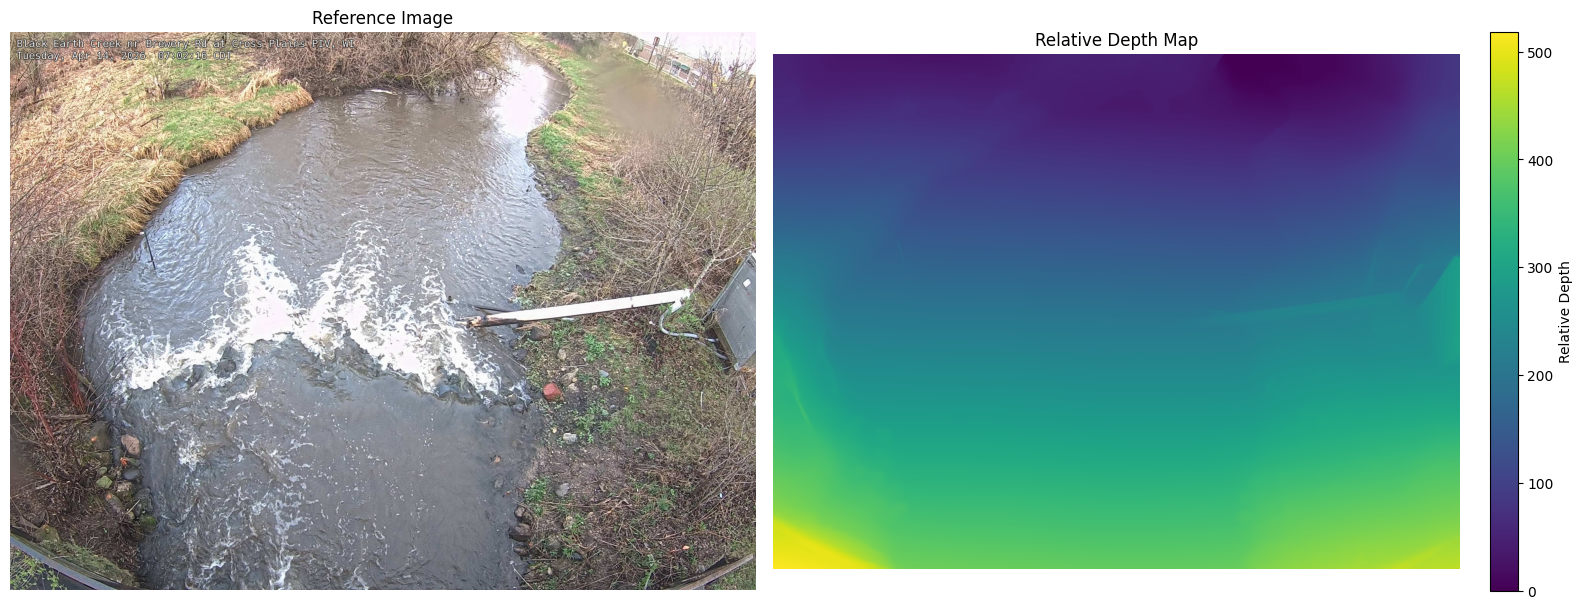

In [73]:
# Display reference image and depth map side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Reference Image')
axes[0].axis('off')

im = axes[1].imshow(depth, cmap='viridis')
axes[1].set_title('Relative Depth Map')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='Relative Depth')

plt.tight_layout()
plt.show()

## Extract Calibration Data

Build a per-pixel elevation map by finding the minimum gage height at which each pixel becomes water. This gives dense ground-truth elevation data across the entire flooded area, not just contour edges.

In [74]:
# Build per-pixel map: minimum elevation at which each pixel becomes water
min_elev_map = np.full(depth.shape, np.nan)

for idx, row in df.iterrows():
    mask_path = os.path.join(masks_dir, row['mask_filename'])
    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found: {mask_path}")
        continue

    mask = np.load(mask_path)
    if mask.ndim == 3:
        mask = mask.squeeze()
    mask = mask.astype(bool)
    elev = row['00065']

    # For each water pixel, track the lowest elevation at which it floods
    update = mask & (np.isnan(min_elev_map) | (elev < min_elev_map))
    min_elev_map[update] = elev

# Extract calibration data from pixels that have been flooded
valid = ~np.isnan(min_elev_map)
ys, xs = np.where(valid)
cal_df = pd.DataFrame({
    'pixel_x': xs,
    'pixel_y': ys,
    'relative_depth': depth[ys, xs],
    'elevation': min_elev_map[ys, xs],
})
cal_df.to_csv(os.path.join(output_dir, 'calibration_data.csv'), index=False)

print(f"Calibration pixels: {len(cal_df)} / {depth.shape[0] * depth.shape[1]}")
print(f"Depth range: {cal_df['relative_depth'].min():.2f} to {cal_df['relative_depth'].max():.2f}")
print(f"Elevation range: {cal_df['elevation'].min():.2f} to {cal_df['elevation'].max():.2f} ft")

Calibration pixels: 1993531 / 3981312
Depth range: 0.00 to 499.08
Elevation range: 2.31 to 2.76 ft


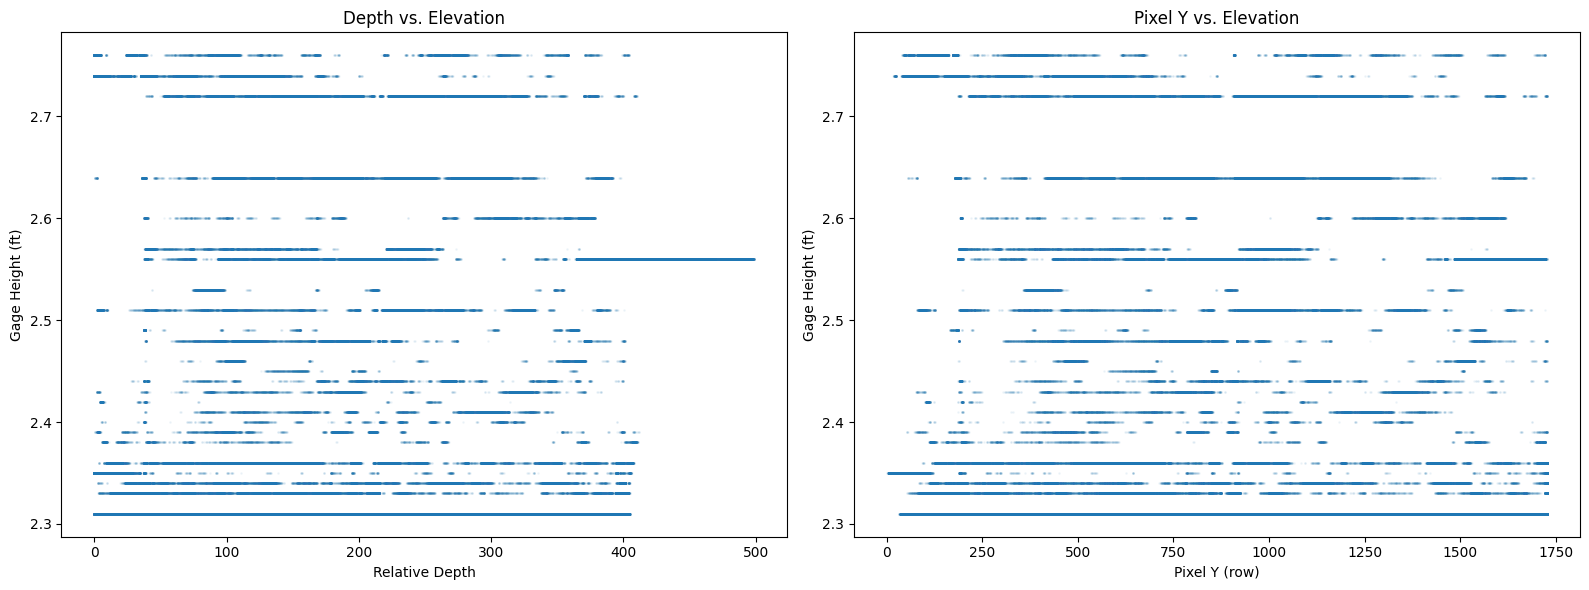

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(cal_df['relative_depth'], cal_df['elevation'], s=1, alpha=0.05)
axes[0].set_xlabel('Relative Depth')
axes[0].set_ylabel('Gage Height (ft)')
axes[0].set_title('Depth vs. Elevation')

axes[1].scatter(cal_df['pixel_y'], cal_df['elevation'], s=1, alpha=0.05)
axes[1].set_xlabel('Pixel Y (row)')
axes[1].set_ylabel('Gage Height (ft)')
axes[1].set_title('Pixel Y vs. Elevation')

plt.tight_layout()
plt.show()

## Fit Calibration

Fit a regression from relative depth and pixel coordinates to gage height (ft). Using depth² + depth + y² + y captures the nonlinear perspective relationship between camera geometry and real-world elevation.

In [76]:
# Build feature matrix: depth², depth, y², y, 1
d = cal_df['relative_depth'].values
y = cal_df['pixel_y'].values.astype(float)
x = cal_df['pixel_x'].values.astype(float)
e = cal_df['elevation'].values

A = np.column_stack([d**2, d, y**2, y, np.ones(len(d))])

coeffs, _, _, _ = np.linalg.lstsq(A, e, rcond=None)

# Quality metrics
predicted = A @ coeffs
residuals = e - predicted
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((e - e.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot
mae = np.mean(np.abs(residuals))
max_err = np.max(np.abs(residuals))

print(f"Features: depth², depth, y², y, 1")
print(f"Coefficients: {coeffs}")
print(f"R²: {r_squared:.4f}")
print(f"MAE: {mae:.3f} ft")
print(f"Max error: {max_err:.3f} ft")

Features: depth², depth, y², y, 1
Coefficients: [ 1.26267018e-06  4.67447597e-03  6.75854458e-09 -1.26314325e-03
  2.42178776e+00]
R²: 0.1824
MAE: 0.032 ft
Max error: 0.447 ft


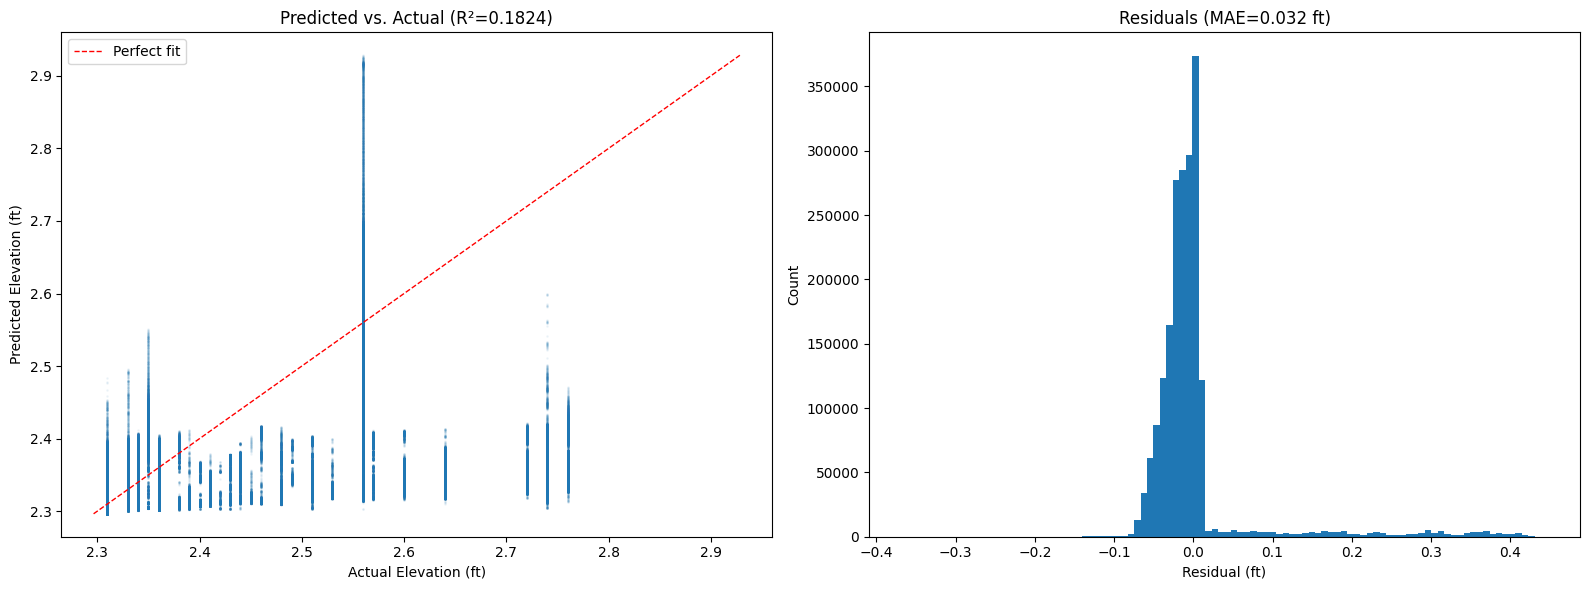

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs actual
axes[0].scatter(e, predicted, s=1, alpha=0.05)
lims = [min(e.min(), predicted.min()), max(e.max(), predicted.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
axes[0].set_xlabel('Actual Elevation (ft)')
axes[0].set_ylabel('Predicted Elevation (ft)')
axes[0].set_title(f'Predicted vs. Actual (R²={r_squared:.4f})')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=100, edgecolor='none')
axes[1].set_xlabel('Residual (ft)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals (MAE={mae:.3f} ft)')

plt.tight_layout()
plt.show()

## Create Elevation Map

Apply the fitted polynomial to the full depth map to produce a calibrated elevation raster.

**Note:** Elevation values outside the observed gage height range are extrapolated and may be unreliable.

In [78]:
# Apply fitted model to full scene: depth², depth, y², y, 1
yy = np.arange(depth.shape[0], dtype=float)
y_grid = np.broadcast_to(yy[:, None], depth.shape)
elevation_map = (coeffs[0] * depth**2 + coeffs[1] * depth
                 + coeffs[2] * y_grid**2 + coeffs[3] * y_grid + coeffs[4])

np.save(os.path.join(output_dir, 'calibrated_elevation.npy'), elevation_map)

print(f"Elevation map shape: {elevation_map.shape}")
print(f"Elevation range: {elevation_map.min():.2f} to {elevation_map.max():.2f} ft")
print(f"Observed gage height range: {cal_df['elevation'].min():.2f} to {cal_df['elevation'].max():.2f} ft")

Elevation map shape: (1728, 2304)
Elevation range: 2.30 to 3.02 ft
Observed gage height range: 2.31 to 2.76 ft


Optional: If the fit looks very poor (such as predicting only 1 value), you can use the raw min elevations with unlabeled areas given the max value instead

In [79]:
# Uncomment to use unfitted elevation map 
non_valid_mask =  np.isnan(min_elev_map)

min_elev_map[non_valid_mask] = np.nanmax(min_elev_map, axis=None)
elevation_map = min_elev_map

np.save(os.path.join(output_dir, 'calibrated_elevation.npy'), elevation_map)

print(f"Elevation map shape: {elevation_map.shape}")
print(f"Elevation range: {elevation_map.min():.2f} to {elevation_map.max():.2f} ft")
print(f"Observed gage height range: {cal_df['elevation'].min():.2f} to {cal_df['elevation'].max():.2f} ft")

Elevation map shape: (1728, 2304)
Elevation range: 2.31 to 2.76 ft
Observed gage height range: 2.31 to 2.76 ft


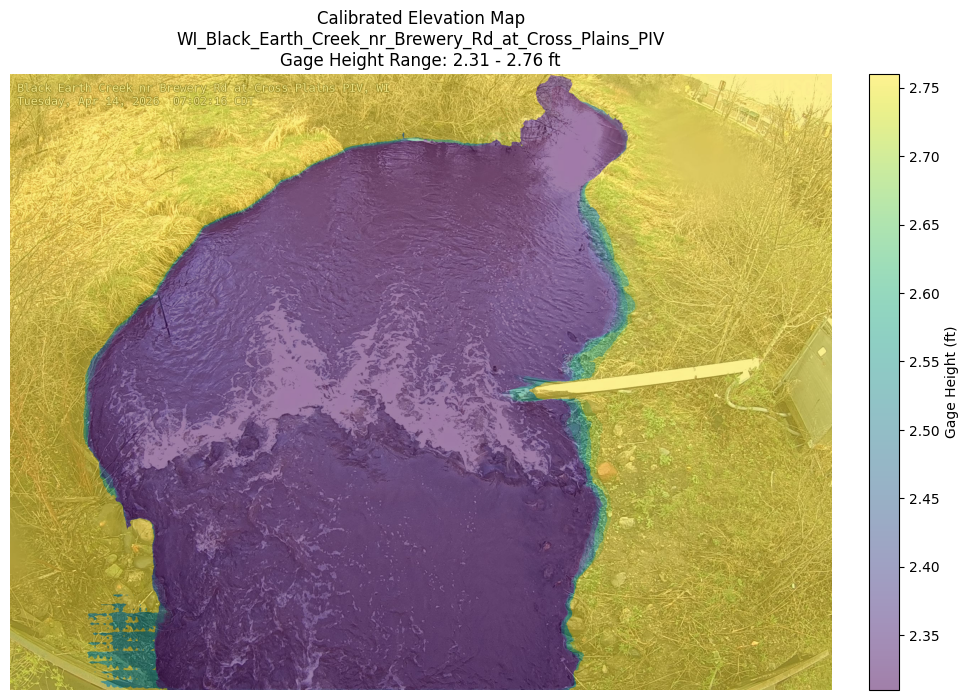

Saved: cameras/WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV/event_04-14-2026/depth/elevation_map_with_background.png


In [80]:
# Elevation map overlaid on reference image
reference_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
min_elev, max_elev = cal_df['elevation'].min(), cal_df['elevation'].max()
norm = Normalize(vmin=min_elev, vmax=max_elev)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(reference_rgb)
im = ax.imshow(elevation_map, cmap='viridis', alpha=0.5, norm=norm)
ax.set_title(f'Calibrated Elevation Map\n{camera_id}\nGage Height Range: {min_elev:.2f} - {max_elev:.2f} ft')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Gage Height (ft)')

output_path = os.path.join(output_dir, 'elevation_map_with_background.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

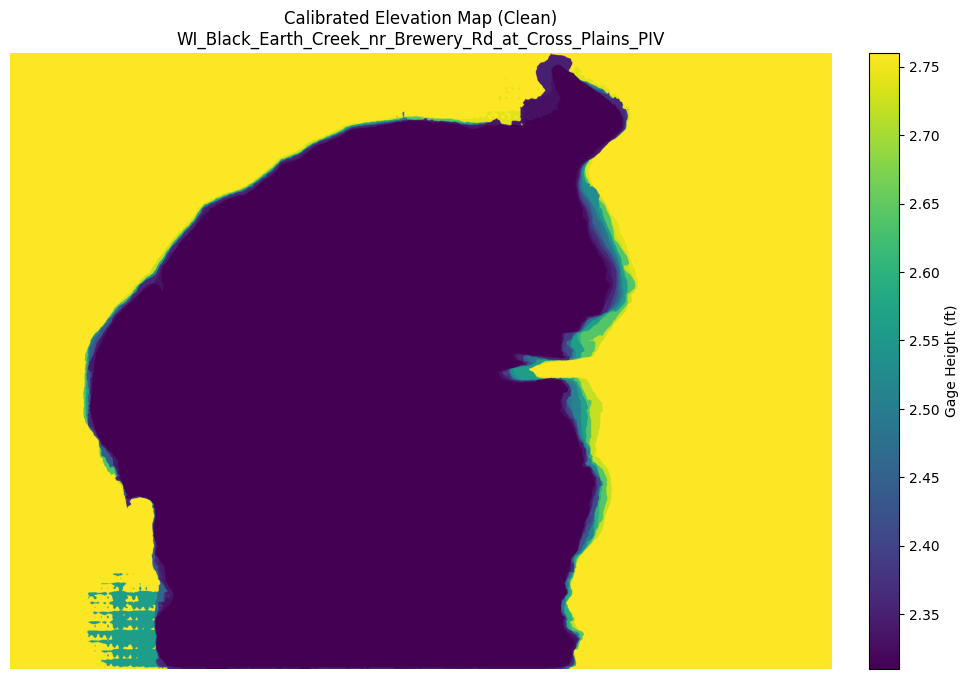

Saved: cameras/WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV/event_04-14-2026/depth/elevation_map_clean.png


In [81]:
# Clean elevation map (no background)
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(elevation_map, cmap='viridis', norm=norm)
ax.set_title(f'Calibrated Elevation Map (Clean)\n{camera_id}')
ax.axis('off')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Gage Height (ft)')

output_path = os.path.join(output_dir, 'elevation_map_clean.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {output_path}")

## Summary

In [82]:
print(f"Output files saved to: {output_dir}")
for f in sorted(os.listdir(output_dir)):
    print(f"  - {f}")

Output files saved to: cameras/WI_Black_Earth_Creek_nr_Brewery_Rd_at_Cross_Plains_PIV/event_04-14-2026/depth
  - calibrated_elevation.npy
  - calibration_data.csv
  - elevation_map_clean.png
  - elevation_map_with_background.png
  - relative_depth.npy
  - relative_depth.png
